# Initial setup

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# prompt: generate the code to change the current working directory to main directory

import os

# Check the current working directory
print(os.getcwd())

# Change the current working directory
os.chdir('/content/drive/MyDrive/Complete Machine Learning/Machine learning/Unsupervised ML Models') # Write the current working directory as parameter

# Check the current working directory
print(os.getcwd())

# List contents of the main directory (root directory)
!ls

/content/drive/MyDrive/Complete Machine Learning/Machine learning/Unsupervised ML Models
/content/drive/MyDrive/Complete Machine Learning/Machine learning/Unsupervised ML Models
 Data  ' K-Means Clustering.ipynb'


# Importing DataFrame

In [74]:
data = pd.read_csv("Data/data.csv", encoding='ISO-8859-1')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


As we can see there is no as such target columns...
therefor it is unisupervised ML problem

In [75]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['InvoiceDate']

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00
...,...
541904,2011-12-09 12:50:00
541905,2011-12-09 12:50:00
541906,2011-12-09 12:50:00
541907,2011-12-09 12:50:00


# EDA

In [76]:
data.shape

(541909, 8)

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


* There exist some NONE in dataset
* Apart from "Quantity, UnitPrice, CustomerID" all columns are of Object Datatype

In [78]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


Discription of non numeric Features

In [79]:
data.describe(exclude = ['float64', 'int64']).T

,count,unique,top,freq,mean,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN


### Null Value

In [80]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [81]:
data['CustomerID'].nunique(), data['InvoiceNo'].nunique()

(4372, 25900)

In [82]:
missing_rows = data[data.isnull().any(axis=1)]
display(missing_rows)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [83]:
wer = pd.DataFrame(missing_rows['InvoiceNo'].value_counts())
wer

,count
InvoiceNo,
573585,1114
581219,749
581492,731
580729,721
558475,705
...,...
537005,1
537004,1
537003,1


In [84]:
missing_rows[missing_rows['InvoiceNo']=='573585']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
430237,573585,11001,ASSTD DESIGN RACING CAR PEN,2,2011-10-31 14:41:00,3.29,NaN,United Kingdom
430238,573585,15036,ASSORTED COLOURS SILK FAN,15,2011-10-31 14:41:00,1.63,NaN,United Kingdom
430239,573585,15039,SANDALWOOD FAN,15,2011-10-31 14:41:00,1.63,NaN,United Kingdom
430240,573585,15056BL,EDWARDIAN PARASOL BLACK,1,2011-10-31 14:41:00,12.46,NaN,United Kingdom
430241,573585,15056N,EDWARDIAN PARASOL NATURAL,1,2011-10-31 14:41:00,12.46,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
431346,573585,90209C,PINK ENAMEL+GLASS HAIR COMB,3,2011-10-31 14:41:00,2.07,NaN,United Kingdom
431347,573585,90214S,"LETTER ""S"" BLING KEY RING",1,2011-10-31 14:41:00,0.83,NaN,United Kingdom
431348,573585,DOT,DOTCOM POSTAGE,1,2011-10-31 14:41:00,2019.05,NaN,United Kingdom
431349,573585,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,1,2011-10-31 14:41:00,16.67,NaN,United Kingdom


In [85]:
missing_rows[missing_rows['InvoiceNo']=='573585'].nunique()

,0
InvoiceNo,1
StockCode,1110
Description,1108
Quantity,42
InvoiceDate,1
UnitPrice,56
CustomerID,0
Country,1


### Handling Null values

In [86]:
data.dropna(inplace = True) #Inplace = True : insted of returning it store the data in "data"
data.shape

(406829, 8)

In [87]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


### Handling negative value

In [88]:
data[data['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [89]:
data[data['UnitPrice']<0].shape

(0, 8)

In [90]:
Negative_values = data[data['Quantity']<0]

In [91]:
data.drop(Negative_values.index, inplace = True)
data.reset_index(drop=True, inplace=True)

In [92]:
data.shape

(397924, 8)

# Feture Extractions

## Calculating total amount and grouping customersID and Total

In [93]:
data['CustomerID'].nunique()

4339

In [94]:
from pandas.core import groupby
data['TotalAmount'] = data['Quantity'] * data['UnitPrice']

newdata = data.groupby('CustomerID')['TotalAmount'].sum().reset_index()
newdata

,CustomerID,TotalAmount
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4334,18280.0,180.60
4335,18281.0,80.82
4336,18282.0,178.05
4337,18283.0,2094.88


## Transaction by each customer

In [95]:
New_trans = data.groupby('CustomerID')['InvoiceNo'].count().reset_index()
New_trans

,CustomerID,InvoiceNo
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4334,18280.0,10
4335,18281.0,7
4336,18282.0,12
4337,18283.0,756


## Last Transaction of date

In [96]:
data['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [97]:
data['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [98]:
data['lastTransaction'] = (data['InvoiceDate'].max() - data['InvoiceDate']).dt.days

In [99]:
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,lastTransaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
...,...,...,...,...,...,...,...,...,...,...
397919,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,0
397920,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,0
397921,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0
397922,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0


In [100]:
lt = data.groupby(['CustomerID', 'Country'])['lastTransaction'].max().reset_index()
lt

,CustomerID,Country,lastTransaction
0,12346.0,United Kingdom,325
1,12347.0,Iceland,366
2,12348.0,Finland,357
3,12349.0,Italy,18
4,12350.0,Norway,309
...,...,...,...
4342,18280.0,United Kingdom,277
4343,18281.0,United Kingdom,180
4344,18282.0,United Kingdom,125
4345,18283.0,United Kingdom,336


## Final - Merge table

In [101]:
merge_table = pd.merge(lt, New_trans, how = 'inner', on = 'CustomerID')
new_df = pd.merge(merge_table, newdata, how = 'inner', on = 'CustomerID')
new_df

,CustomerID,Country,lastTransaction,InvoiceNo,TotalAmount
0,12346.0,United Kingdom,325,1,77183.60
1,12347.0,Iceland,366,182,4310.00
2,12348.0,Finland,357,31,1797.24
3,12349.0,Italy,18,73,1757.55
4,12350.0,Norway,309,17,334.40
...,...,...,...,...,...
4342,18280.0,United Kingdom,277,10,180.60
4343,18281.0,United Kingdom,180,7,80.82
4344,18282.0,United Kingdom,125,12,178.05
4345,18283.0,United Kingdom,336,756,2094.88


# EDA on ```new_df```

In [102]:
display(new_df.head())
display(new_df.tail())
display(new_df.sample(5))

,CustomerID,Country,lastTransaction,InvoiceNo,TotalAmount
0,12346.0,United Kingdom,325,1,77183.60
1,12347.0,Iceland,366,182,4310.00
2,12348.0,Finland,357,31,1797.24
3,12349.0,Italy,18,73,1757.55
4,12350.0,Norway,309,17,334.40


,CustomerID,Country,lastTransaction,InvoiceNo,TotalAmount
4342,18280.0,United Kingdom,277,10,180.60
4343,18281.0,United Kingdom,180,7,80.82
4344,18282.0,United Kingdom,125,12,178.05
4345,18283.0,United Kingdom,336,756,2094.88
4346,18287.0,United Kingdom,201,70,1837.28


,CustomerID,Country,lastTransaction,InvoiceNo,TotalAmount
1737,14700.0,United Kingdom,237,115,2235.30
1771,14747.0,United Kingdom,248,18,328.20
4064,17896.0,United Kingdom,22,2,256.32
1746,14711.0,United Kingdom,261,357,2868.80
4148,18013.0,United Kingdom,154,31,187.29


In [103]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4347 entries, 0 to 4346
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       4347 non-null   float64
 1   Country          4347 non-null   object 
 2   lastTransaction  4347 non-null   int64  
 3   InvoiceNo        4347 non-null   int64  
 4   TotalAmount      4347 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 169.9+ KB


In [104]:
new_df.nunique()

,0
CustomerID,4339
Country,37
lastTransaction,358
InvoiceNo,461
TotalAmount,4254


## Removal of outlier

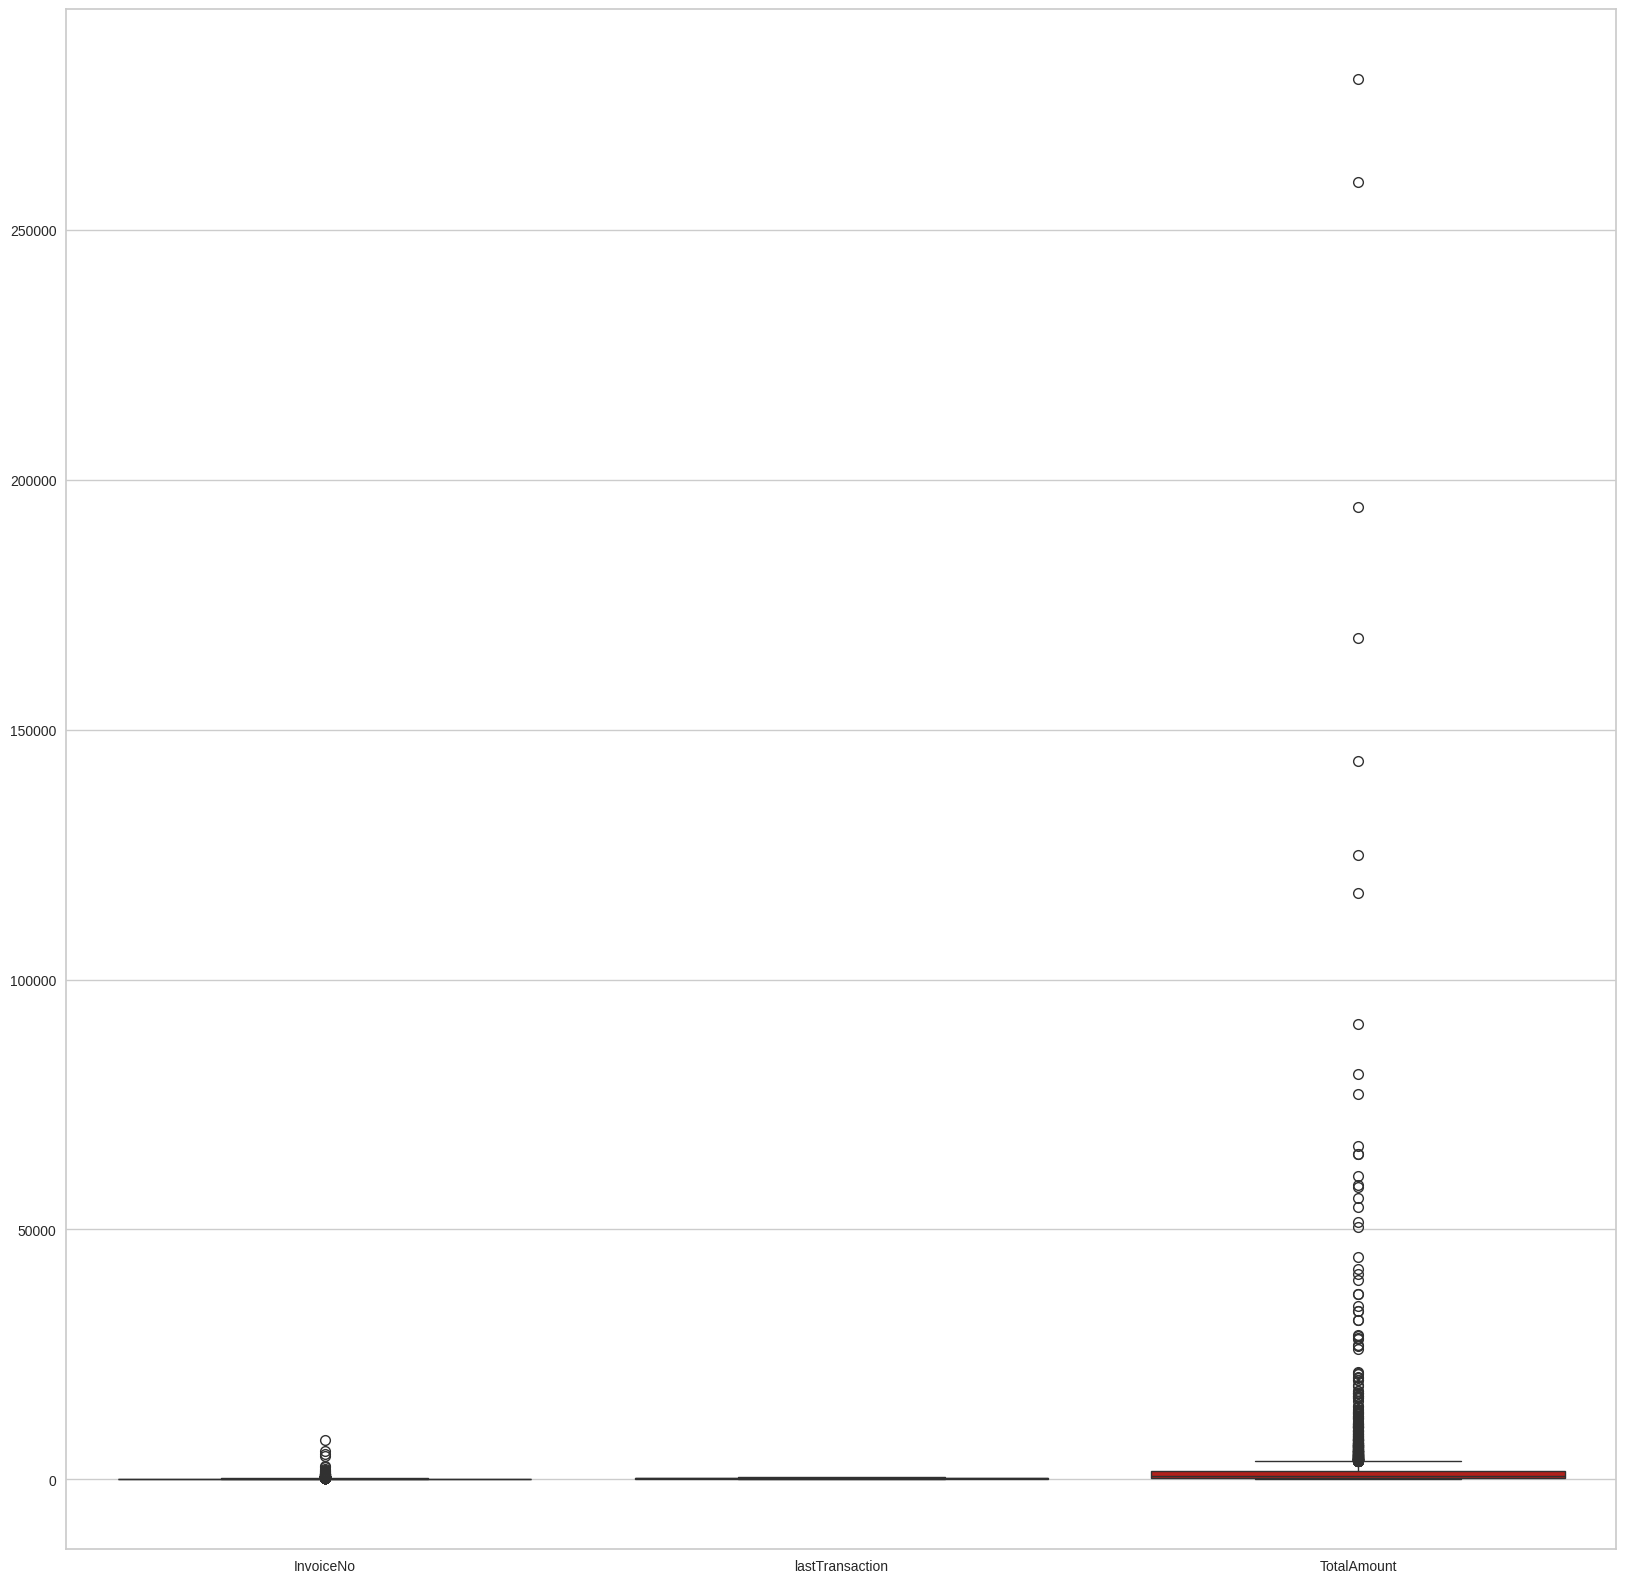

In [105]:
plt.figure(figsize= (20,20))
sns.boxplot(data = new_df[['InvoiceNo', 'lastTransaction', 'TotalAmount']])
plt.show()

In [106]:
new_df.describe()

,CustomerID,lastTransaction,InvoiceNo,TotalAmount
count,4347.000000,4347.000000,4347.000000,4347.000000
mean,15294.640212,222.219692,91.749482,2055.612301
std,1724.722441,117.878338,228.604503,8980.352817
min,12346.000000,0.000000,1.000000,0.000000
25%,13806.500000,112.000000,17.000000,307.470000
50%,15292.000000,248.000000,41.000000,675.270000
75%,16776.500000,326.000000,100.000000,1671.330000
max,18287.000000,373.000000,7847.000000,280206.020000


In [107]:
new_df['TotalAmount'].quantile(0.75), new_df['TotalAmount'].quantile(0.25)

(np.float64(1671.33), np.float64(307.47))

In [108]:
IQR = new_df['TotalAmount'].quantile(0.75) - new_df['TotalAmount'].quantile(0.25)
Lower_limit = new_df['TotalAmount'].quantile(0.25) - 1.5*IQR
upper_limit = new_df['TotalAmount'].quantile(0.75) + 1.5*IQR

new_df_IQR = new_df[(new_df['TotalAmount']< upper_limit) & (new_df['TotalAmount']> Lower_limit)]

IQR, Lower_limit, upper_limit, new_df_IQR.shape

(np.float64(1363.86), np.float64(-1738.32), np.float64(3717.12), (3923, 5))

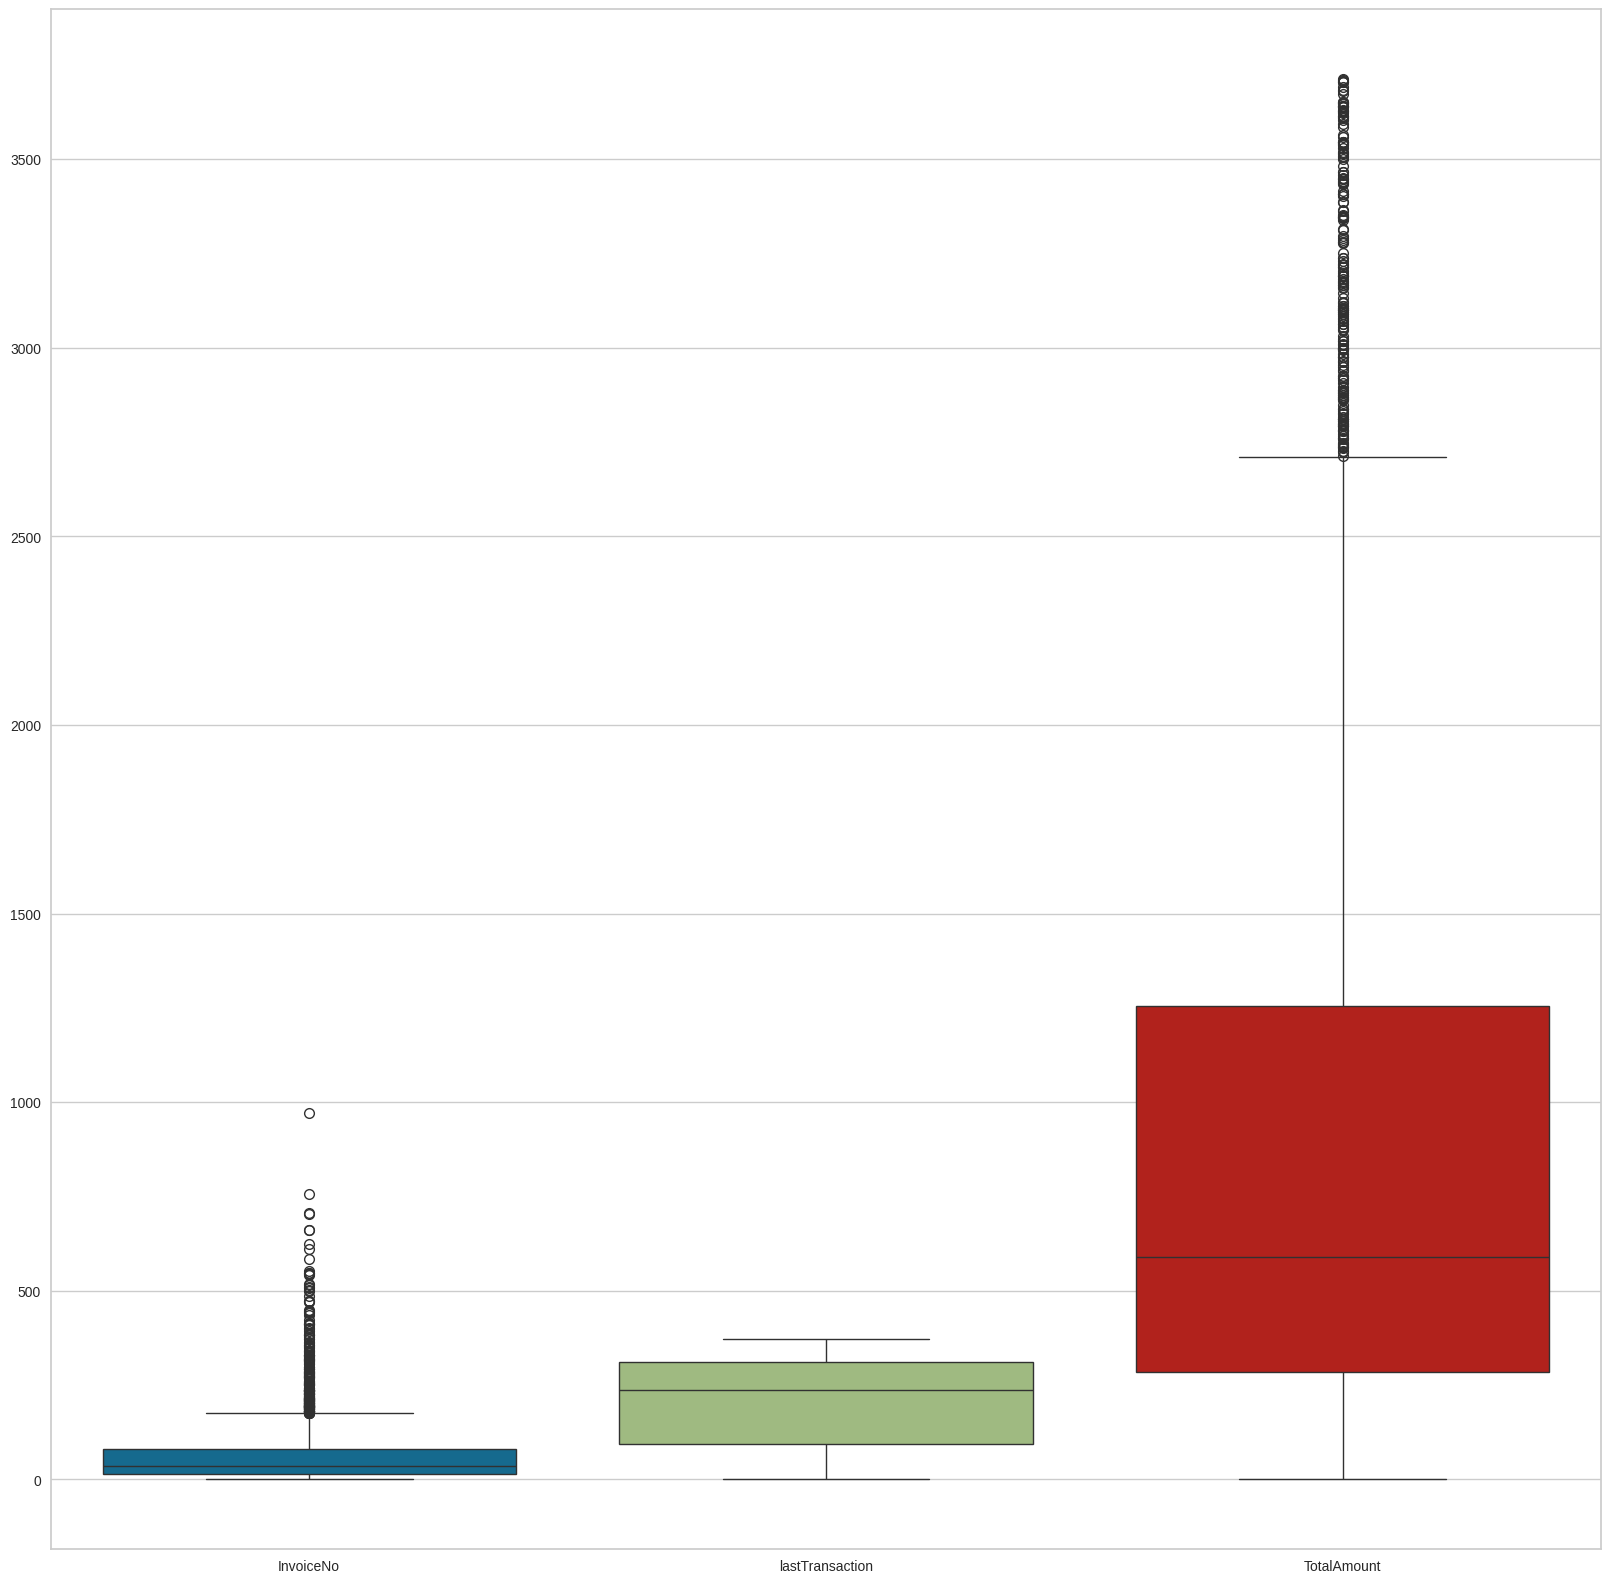

In [109]:
plt.figure(figsize= (20,20))
sns.boxplot(data = new_df_IQR[['InvoiceNo', 'lastTransaction', 'TotalAmount']])
plt.show()

In [110]:
new_df_IQR.reset_index(drop = True, inplace = True)
new_df_IQR

,CustomerID,Country,lastTransaction,InvoiceNo,TotalAmount
0,12348.0,Finland,357,31,1797.24
1,12349.0,Italy,18,73,1757.55
2,12350.0,Norway,309,17,334.40
3,12352.0,Norway,296,85,2506.04
4,12353.0,Bahrain,203,4,89.00
...,...,...,...,...,...
3918,18280.0,United Kingdom,277,10,180.60
3919,18281.0,United Kingdom,180,7,80.82
3920,18282.0,United Kingdom,125,12,178.05
3921,18283.0,United Kingdom,336,756,2094.88


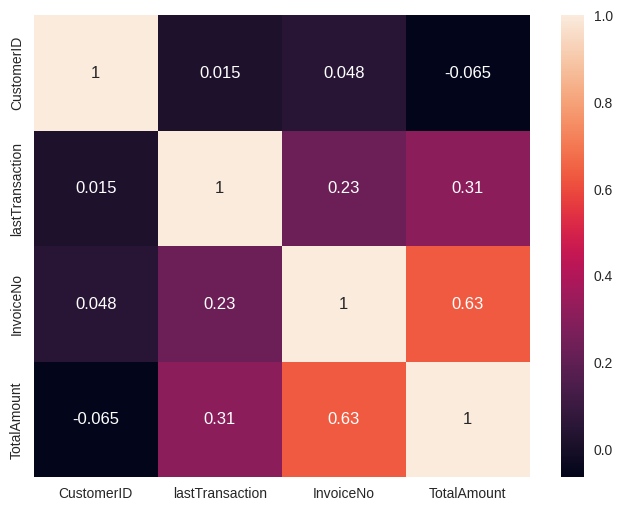

In [111]:
plt.figure(figsize=(8,6))
sns.heatmap(new_df_IQR.corr(numeric_only= True), annot = True)
plt.show()

## Normalization using MinMaxScaler

In [112]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [113]:
new2 = new_df_IQR[['lastTransaction',	'InvoiceNo', 'TotalAmount']]
scaled_df = scaler.fit_transform(new2)
scaled_df = pd.DataFrame(scaled_df)
scaled_df.columns = ['lastTransaction',	'InvoiceNo', 'TotalAmount']
scaled_df

,lastTransaction,InvoiceNo,TotalAmount
0,0.957105,0.030960,0.484200
1,0.048257,0.074303,0.473507
2,0.828418,0.016512,0.090092
3,0.793566,0.086687,0.675160
4,0.544236,0.003096,0.023978
...,...,...,...
3918,0.742627,0.009288,0.048656
3919,0.482574,0.006192,0.021774
3920,0.335121,0.011352,0.047969
3921,0.900804,0.779154,0.564388


# K- Means Clustering

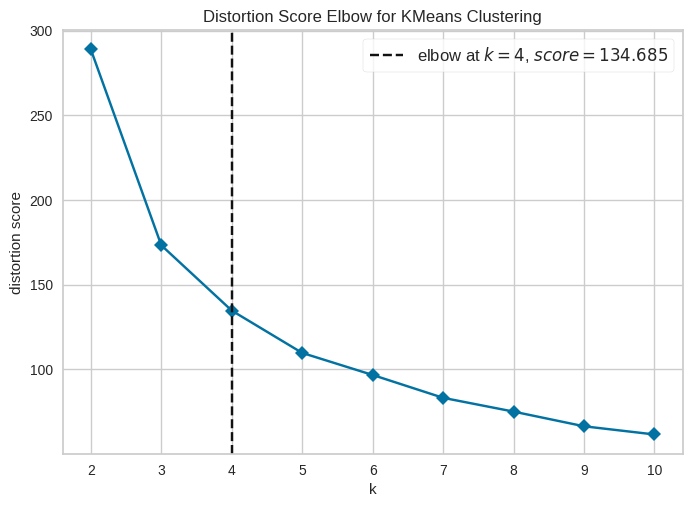

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [139]:
#!pip install yellowbrick
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k = 10,timings= False)
visualizer.fit(scaled_df)
visualizer.show()

In [140]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(scaled_df)
scaled_df["Clusters"] = y_pred
scaled_df

,lastTransaction,InvoiceNo,TotalAmount,Clusters
0,0.957105,0.030960,0.484200,0
1,0.048257,0.074303,0.473507,1
2,0.828418,0.016512,0.090092,2
3,0.793566,0.086687,0.675160,0
4,0.544236,0.003096,0.023978,2
...,...,...,...,...
3918,0.742627,0.009288,0.048656,2
3919,0.482574,0.006192,0.021774,1
3920,0.335121,0.011352,0.047969,1
3921,0.900804,0.779154,0.564388,0


In [141]:
km.cluster_centers_

array([[0.79796367, 0.15825709, 0.63324065],
       [0.22076895, 0.04001774, 0.14851301],
       [0.77665026, 0.04271404, 0.15749496]])

In [142]:
from sklearn.metrics import silhouette_score, silhouette_samples
score_KM = silhouette_score(scaled_df, scaled_df['Clusters'])
print(score_KM)

0.7825091729783354


In [143]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_KM = silhouette_score(scaled_df, km.labels_, metric='euclidean')
print(score_KM)

0.7825091729783354


In [144]:
scaled_df

,lastTransaction,InvoiceNo,TotalAmount,Clusters
0,0.957105,0.030960,0.484200,0
1,0.048257,0.074303,0.473507,1
2,0.828418,0.016512,0.090092,2
3,0.793566,0.086687,0.675160,0
4,0.544236,0.003096,0.023978,2
...,...,...,...,...
3918,0.742627,0.009288,0.048656,2
3919,0.482574,0.006192,0.021774,1
3920,0.335121,0.011352,0.047969,1
3921,0.900804,0.779154,0.564388,0


In [118]:
scaled_df = scaled_df.iloc[:, :3]
scaled_df

,lastTransaction,InvoiceNo,TotalAmount
0,0.957105,0.030960,0.484200
1,0.048257,0.074303,0.473507
2,0.828418,0.016512,0.090092
3,0.793566,0.086687,0.675160
4,0.544236,0.003096,0.023978
...,...,...,...
3918,0.742627,0.009288,0.048656
3919,0.482574,0.006192,0.021774
3920,0.335121,0.011352,0.047969
3921,0.900804,0.779154,0.564388


# Hierarchical Clustering

```
class sklearn.cluster.AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
```
*linkage* : {'ward, 'complete', 'average', 'single'}, default='ward'
* **'ward'** minimizes the variance of the clusters being merged.  
* **'average'** uses the average of the distances of each observation of the two sets.  
* **'complete'** or 'maximum' linkage uses the maximum distances between all observations of the two sets.  
* **'single'** uses the minimum of the distances between all observations of the two sets.

In [119]:
from sklearn.cluster import AgglomerativeClustering
hierarchial = AgglomerativeClustering(n_clusters=3)
y_predicted_hierarchial = hierarchial.fit_predict(scaled_df)
scaled_df['clusters_hierarchial'] = y_predicted_hierarchial
scaled_df

,lastTransaction,InvoiceNo,TotalAmount,clusters_hierarchial
0,0.957105,0.030960,0.484200,2
1,0.048257,0.074303,0.473507,0
2,0.828418,0.016512,0.090092,1
3,0.793566,0.086687,0.675160,2
4,0.544236,0.003096,0.023978,0
...,...,...,...,...
3918,0.742627,0.009288,0.048656,1
3919,0.482574,0.006192,0.021774,0
3920,0.335121,0.011352,0.047969,0
3921,0.900804,0.779154,0.564388,2


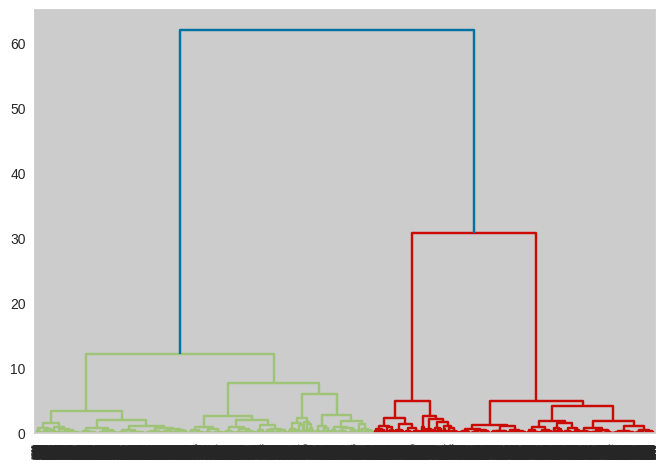

In [120]:
from scipy.cluster.hierarchy import *
import matplotlib.pyplot as plt
m = linkage(scaled_df,"ward")
dendrogram(m)
plt.show()

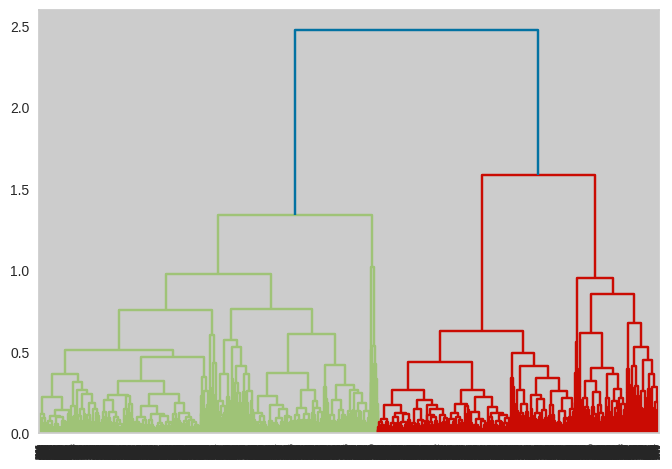

In [121]:
from scipy.cluster.hierarchy import *
import matplotlib.pyplot as plt
m = linkage(scaled_df,"complete")
dendrogram(m)
plt.show()

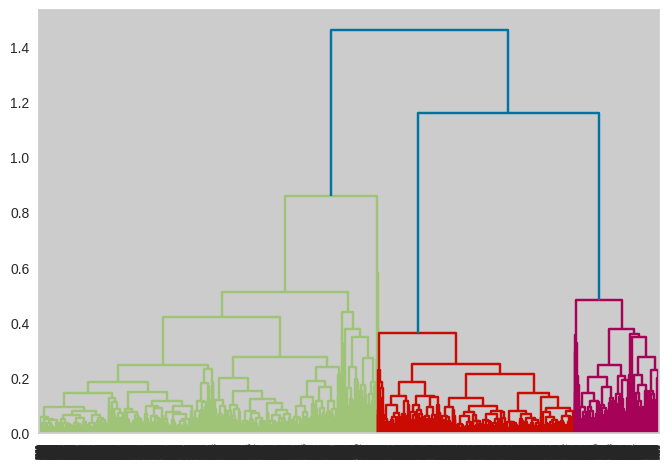

In [122]:
from scipy.cluster.hierarchy import *
import matplotlib.pyplot as plt
m = linkage(scaled_df,"average")
dendrogram(m)
plt.show()

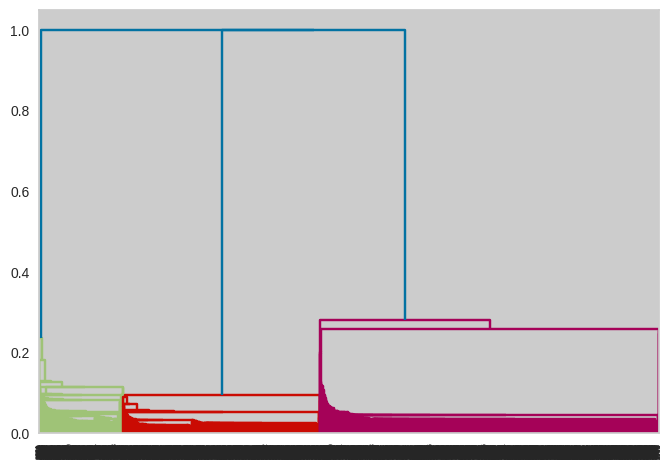

In [123]:
from scipy.cluster.hierarchy import *
import matplotlib.pyplot as plt
m = linkage(scaled_df,"single")
dendrogram(m)
plt.show()

In [124]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_hierarchial = silhouette_score(scaled_df, scaled_df['clusters_hierarchial'])
print(score_hierarchial)

0.7448764683563276


In [125]:
scaled_df = scaled_df.iloc[:, :3]
scaled_df

,lastTransaction,InvoiceNo,TotalAmount
0,0.957105,0.030960,0.484200
1,0.048257,0.074303,0.473507
2,0.828418,0.016512,0.090092
3,0.793566,0.086687,0.675160
4,0.544236,0.003096,0.023978
...,...,...,...
3918,0.742627,0.009288,0.048656
3919,0.482574,0.006192,0.021774
3920,0.335121,0.011352,0.047969
3921,0.900804,0.779154,0.564388


# DB SCAN


In [145]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 0.2, min_samples = 4)
y_pred = dbscan.fit_predict(scaled_df)
scaled_df['Clusters_DBSCAN'] = y_pred

In [146]:
scaled_df

,lastTransaction,InvoiceNo,TotalAmount,Clusters,Clusters_DBSCAN
0,0.957105,0.030960,0.484200,0,0
1,0.048257,0.074303,0.473507,1,1
2,0.828418,0.016512,0.090092,2,2
3,0.793566,0.086687,0.675160,0,0
4,0.544236,0.003096,0.023978,2,2
...,...,...,...,...,...
3918,0.742627,0.009288,0.048656,2,2
3919,0.482574,0.006192,0.021774,1,1
3920,0.335121,0.011352,0.047969,1,1
3921,0.900804,0.779154,0.564388,0,0


In [147]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_dbscan = silhouette_score(scaled_df, scaled_df['Clusters_DBSCAN'])

print(score_dbscan)

0.8259207599235644


In [148]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_dbscan = silhouette_score(scaled_df, dbscan.labels_, metric='euclidean')
print(score_dbscan)

0.8259207599235644


In [138]:
scaled_df = scaled_df.iloc[:, :3]
scaled_df

,lastTransaction,InvoiceNo,TotalAmount
0,0.957105,0.030960,0.484200
1,0.048257,0.074303,0.473507
2,0.828418,0.016512,0.090092
3,0.793566,0.086687,0.675160
4,0.544236,0.003096,0.023978
...,...,...,...
3918,0.742627,0.009288,0.048656
3919,0.482574,0.006192,0.021774
3920,0.335121,0.011352,0.047969
3921,0.900804,0.779154,0.564388


# Evaluation Metric: Silhouette Score

In [130]:
silhouette_score

<function sklearn.metrics.cluster._unsupervised.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)>

In [131]:
scaled_df

,lastTransaction,InvoiceNo,TotalAmount
0,0.957105,0.030960,0.484200
1,0.048257,0.074303,0.473507
2,0.828418,0.016512,0.090092
3,0.793566,0.086687,0.675160
4,0.544236,0.003096,0.023978
...,...,...,...
3918,0.742627,0.009288,0.048656
3919,0.482574,0.006192,0.021774
3920,0.335121,0.011352,0.047969
3921,0.900804,0.779154,0.564388


In [132]:
print(score_KM)
print(score_hierarchial)
print(score_dbscan)

0.7738282311030276
0.7448764683563276
0.6521458274439181
